<a href="https://colab.research.google.com/github/jonumhills/water-data-analysis/blob/main/WaterDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# State Exploration
statesurl = "https://api.waterdata.usgs.gov/ogcapi/v0/collections/states/items?f=json&lang=en-US&limit=10000&skipGeometry=false&offset=0"
states = requests.get(statesurl).json()
# print(states.keys())
# print(states["features"][0])
df_states = pd.DataFrame([f['properties'] for f in states['features']])
# print(df_states.head(10))

#New Mexico Row data
print(df_states[df_states['state_name'] == 'New Mexico'])

       id country_code state_fips_code  state_name state_postal_code
91  US-35           US              35  New Mexico                NM


In [6]:
# Parameter API - Discharge
params_url = "https://api.waterdata.usgs.gov/ogcapi/v0/collections/parameter-codes/items?f=json&limit=100"
response = requests.get(params_url).json()
# print(response)

# Getting 'properties' of each feature
df_params = pd.DataFrame([f['properties'] for f in response['features']])
# print(df_params.head(10))
print(df_params[df_params["parameter_name"] == "Discharge"])

       id parameter_name unit_of_measure parameter_group_code  \
42  00060      Discharge           ft3/s                  PHY   

               parameter_description medium statistical_basis time_basis  \
42  Discharge, cubic feet per second  Water              Mean      1 Day   

   weight_basis particle_size_basis sample_fraction temperature_basis  \
42         None                None            None              None   

   epa_equivalence  
42     Not checked  


In [7]:
#Explore Monitoring Locations
url = "https://api.waterdata.usgs.gov/ogcapi/v0/collections/time-series-metadata/items?f=json&lang=en-US&limit=100&skipGeometry=false&offset=0&parameter_name=Discharge&parameter_code=00060&state_name=New%20Mexico"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()

    # Getting 'properties' of each feature
    features = data.get('features', [])
    df = pd.DataFrame([f['properties'] for f in features])

    # Print unique monitoring_location_id values
    if 'monitoring_location_id' in df.columns:
        unique_ids = df['monitoring_location_id'].unique()
        print(f"Found {len(unique_ids)} unique Monitoring Location IDs in this batch:")
        for site_id in unique_ids:
            print(site_id)
    else:
        print("Column 'monitoring_location_id' not found in response properties.")
else:
    print(f"Failed to fetch data. Status code: {response.status_code}")

Found 93 unique Monitoring Location IDs in this batch:
USGS-08484500
USGS-08351400
USGS-08278500
USGS-07201200
USGS-09350800
USGS-08330580
USGS-08313225
USGS-07153400
USGS-07216500
USGS-09356500
USGS-08387575
USGS-08279000
USGS-08397620
USGS-08317950
USGS-083299395
USGS-08387550
USGS-08382000
USGS-08396000
USGS-08330492
USGS-09442666
USGS-08284100
USGS-08386850
USGS-08329914
USGS-08388000
USGS-08406500
USGS-08481500
USGS-08281400
USGS-08343300
USGS-08408500
USGS-09364500
USGS-08363100
USGS-08264500
USGS-08329936
USGS-08405500
USGS-08385522
USGS-08313230
USGS-08405350
USGS-07202400
USGS-08379500
USGS-08319945
USGS-08278000
USGS-08477500
USGS-08399500
USGS-08333500
USGS-08385670
USGS-08341500
USGS-08390020
USGS-09387300
USGS-08264000
USGS-08361800
USGS-08263500
USGS-08317700
USGS-08396500
USGS-07214670
USGS-08340500
USGS-08329838
USGS-08379187
USGS-09442677
USGS-08389060
USGS-08253500
USGS-09431500
USGS-08282300
USGS-08267500
USGS-09432000
USGS-09442760
USGS-08294210
USGS-08329939
USGS-0

In [8]:
# Random 10 IDs from your previous batch
ids = [
    "USGS-09430500", "USGS-08351400", "USGS-08278500", "USGS-07201200",
    "USGS-09350800", "USGS-08330580", "USGS-08313225", "USGS-07153400",
    "USGS-07216500", "USGS-09356500"
]

site_names = []

for site_id in ids:
    # Query the monitoring-locations collection for the specific site details
    url = f"https://api.waterdata.usgs.gov/ogcapi/v0/collections/monitoring-locations/items/{site_id}"
    response = requests.get(url)

    if response.status_code == 200:
        props = response.json().get('properties', {})
        site_names.append({
            "monitoring_location_id": site_id,
            "monitoring_location_name": props.get('monitoring_location_name', 'Name Not Found')
        })

df_names = pd.DataFrame(site_names)
print(df_names)

  monitoring_location_id                           monitoring_location_name
0          USGS-09430500                           GILA RIVER NEAR GILA, NM
1          USGS-08351400                    ARROYO COLORADO NEAR CORREO, NM
2          USGS-08278500                   RIO SANTA BARBARA NR PENASCO, NM
3          USGS-07201200                     CHICORICA CR TRIB NR RATON, NM
4          USGS-09350800                  VAQUEROS CANYON NR GOBERNADOR, NM
5          USGS-08330580  TIJERAS ARROYO AT MONTESSA PARK NR ALBUQUERQUE...
6          USGS-08313225               CANADA DEL BUEY ABOVE WHITE ROCK, NM
7          USGS-07153400                   DRY CIMARRON RIVER AT FOLSOM, NM
8          USGS-07216500                    MORA RIVER NEAR GOLONDRINAS, NM
9          USGS-09356500                           SAN JUAN R NR BLANCO, NM


In [9]:
# API Endpoint for Continuous (IV) Data
url = "https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous/items"

# Define Query Parameters
params = {
    "monitoring_location_id": "USGS-09430500", # Gila River
    "parameter_code": "00060",               # Discharge
    "time": "P90D",                          # Duration - last 30 days
    "f": "json",                             # GeoJSON format
    "limit": 5000
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    print(f"Successfully retrieved {len(data['features'])} data points.")
else:
    print(f"Error {response.status_code}: {response.text}")

Successfully retrieved 5000 data points.


In [10]:
# 1. Parse JSON features into a flat DataFrame
df = pd.DataFrame([f['properties'] for f in data['features']])
# print(df.info())
# print(df.head(3))

# Creating a copy of Data and Renaming the columns
df = df[['time', 'value']].copy()
df.columns = ['timestamp', 'discharge_cfs']

# Convert Timestamp to UTC
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

# print(df.head(3))

# Converting Value from Obj to Numeric
df['discharge_cfs'] = pd.to_numeric(df['discharge_cfs'], errors='coerce')

# 5. Handling Missing Values
# Negative values often represent sensor errors or missing data in USGS datasets
df.loc[df['discharge_cfs'] < 0, 'discharge_cfs'] = np.nan
df = df.dropna(subset=['discharge_cfs'])

print("Data cleaning complete.")
df.info()

Data cleaning complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   timestamp      5000 non-null   datetime64[ns, UTC]
 1   discharge_cfs  5000 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 78.3 KB


In [11]:
# 1. Generate Summary Statistics
summary_stats = {
    "total_obs": len(df),
    "min_val": df['discharge_cfs'].min(),
    "max_val": df['discharge_cfs'].max(),
    "avg_val": df['discharge_cfs'].mean(),
    "latest": df.iloc[-1]
}

# 2. Print Summary to Console
print("--- WATER DATA SUMMARY: Gila River, NM ---")
print(f"Number of Observations: {summary_stats['total_obs']}")
print(f"Min Discharge: {summary_stats['min_val']:.2f} ft3/s")
print(f"Max Discharge: {summary_stats['max_val']:.2f} ft3/s")
print(f"Average Discharge: {summary_stats['avg_val']:.2f} ft3/s")
print(f"Most Recent: {summary_stats['latest']['discharge_cfs']:.2f} ft3/s at {summary_stats['latest']['timestamp']}")

--- WATER DATA SUMMARY: Gila River, NM ---
Number of Observations: 5000
Min Discharge: 55.80 ft3/s
Max Discharge: 108.00 ft3/s
Average Discharge: 70.07 ft3/s
Most Recent: 68.10 ft3/s at 2026-01-17 18:15:00+00:00


Plot generated and saved as 'discharge_plot.png'.


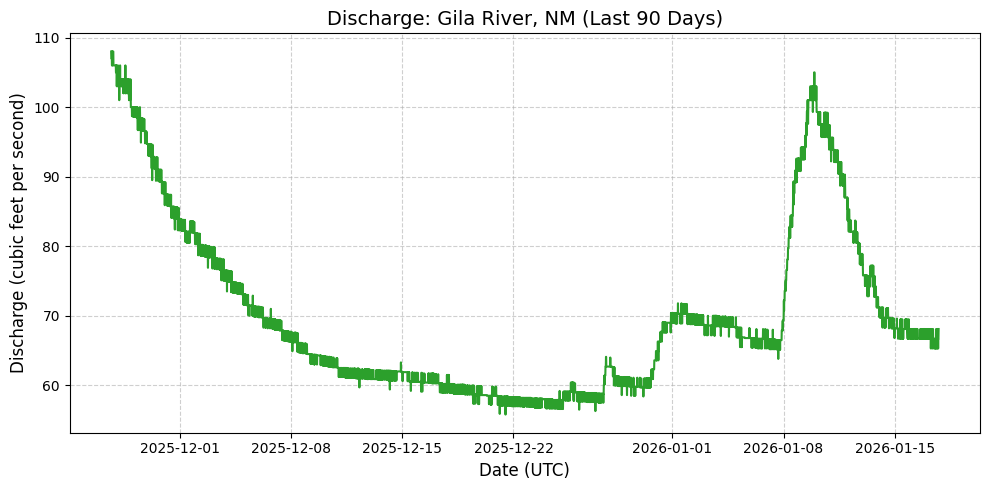

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(df['timestamp'], df['discharge_cfs'], color='tab:green', linewidth=1.5)

# Adding labels and title
plt.title('Discharge: Gila River, NM (Last 90 Days)', fontsize=14)
plt.xlabel('Date (UTC)', fontsize=12)
plt.ylabel('Discharge (cubic feet per second)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save plot to file (optional but good practice)
plt.savefig('discharge_plot.png')
print("Plot generated and saved as 'discharge_plot.png'.")

In [13]:
output_file = "cleaned_gila_river_data.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned dataset saved successfully to {output_file}.")

Cleaned dataset saved successfully to cleaned_gila_river_data.csv.


MORA RIVER: Successfully processed 4075 data points.

--- STATISTICAL SUMMARIES ---
Gila Avg Discharge: 70.07 ft3/s
Mora River Avg Discharge: 21.16 ft3/s


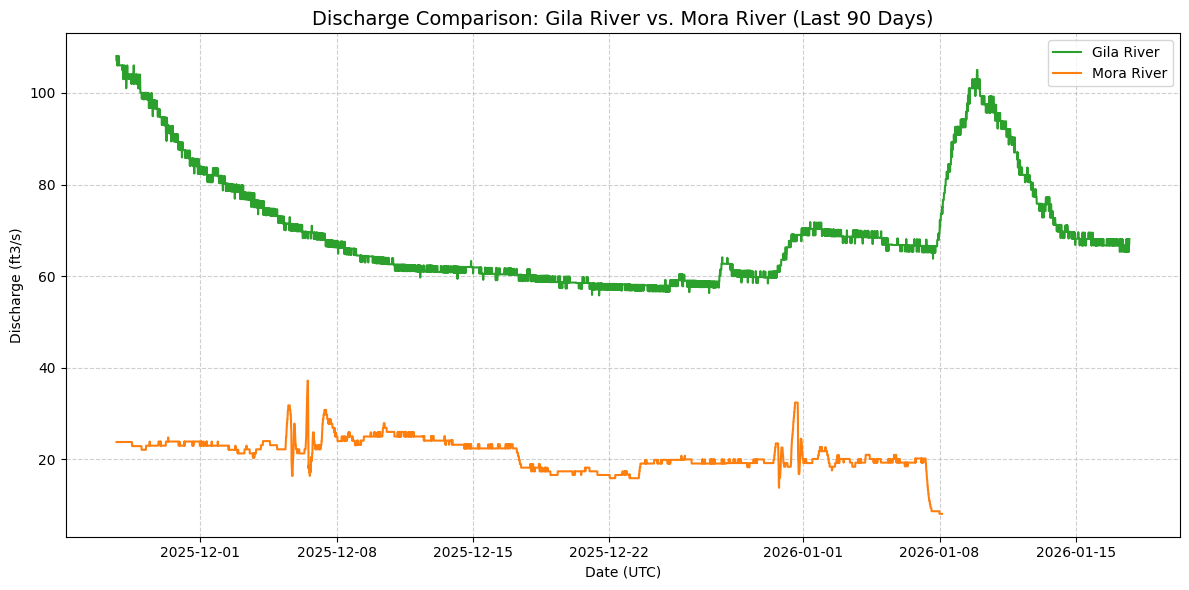

In [20]:
#  MORA RIVER DATA RETRIEVAL (USGS-08351400) ---
url_ac = "https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous/items"
params_ac = {
    "monitoring_location_id": "USGS-07216500", # MORA RIVER
    "parameter_code": "00060",
    "time": "P90D",
    "f": "json",
    "limit": 5000
}

df_gila = df
response_ac = requests.get(url_ac, params=params_ac)
data_ac = response_ac.json()

if len(data_ac['features']) > 0:
    df_ac = pd.DataFrame([f['properties'] for f in data_ac['features']])
    df_ac = df_ac[['time', 'value']].copy()
    df_ac.columns = ['timestamp', 'discharge_cfs']
    df_ac['timestamp'] = pd.to_datetime(df_ac['timestamp'], utc=True)
    df_ac['discharge_cfs'] = pd.to_numeric(df_ac['discharge_cfs'], errors='coerce')
    df_ac.loc[df_ac['discharge_cfs'] < 0, 'discharge_cfs'] = np.nan
    df_ac = df_ac.dropna(subset=['discharge_cfs'])
    print(f"MORA RIVER: Successfully processed {len(df_ac)} data points.")
else:
    print("MORA RIVER: No data found for the requested period.")
    df_ac = pd.DataFrame()

# --- 3. SUMMARIES AND PLOTTING ---
if not df_gila.empty and not df_ac.empty:
    print("\n--- STATISTICAL SUMMARIES ---")
    print(f"Gila Avg Discharge: {df_gila['discharge_cfs'].mean():.2f} ft3/s")
    print(f"Mora River Avg Discharge: {df_ac['discharge_cfs'].mean():.2f} ft3/s")

    plt.figure(figsize=(12, 6))
    plt.plot(df_gila['timestamp'], df_gila['discharge_cfs'], color='tab:green', label='Gila River')
    plt.plot(df_ac['timestamp'], df_ac['discharge_cfs'], color='tab:orange', label='Mora River')
    plt.title('Discharge Comparison: Gila River vs. Mora River (Last 90 Days)', fontsize=14)
    plt.xlabel('Date (UTC)')
    plt.ylabel('Discharge (ft3/s)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("\nInsufficient data for comparison plotting.")